Dataset Shape : (400, 4096)
Number of Classes : 40


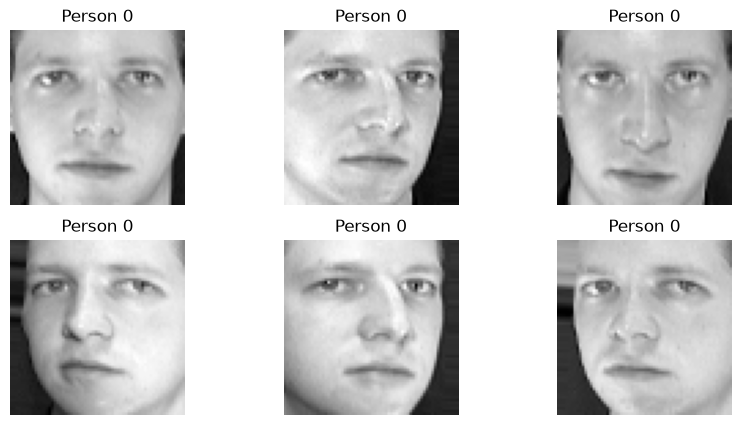

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hp\AppData\Local\Programs\Python\Pytho


Accuracy = 0.79

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.00      0.00      0.00         2
           2       1.00      0.50      0.67         2
           3       1.00      0.75      0.86         4
           4       1.00      0.67      0.80         3
           5       0.75      1.00      0.86         3
           6       0.00      0.00      0.00         1
           7       1.00      0.57      0.73         7
           8       0.67      1.00      0.80         2
           9       0.75      1.00      0.86         3
          10       1.00      0.67      0.80         3
          11       1.00      1.00      1.00         4
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.

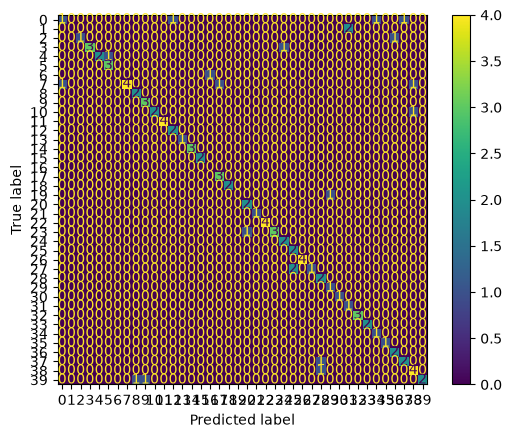

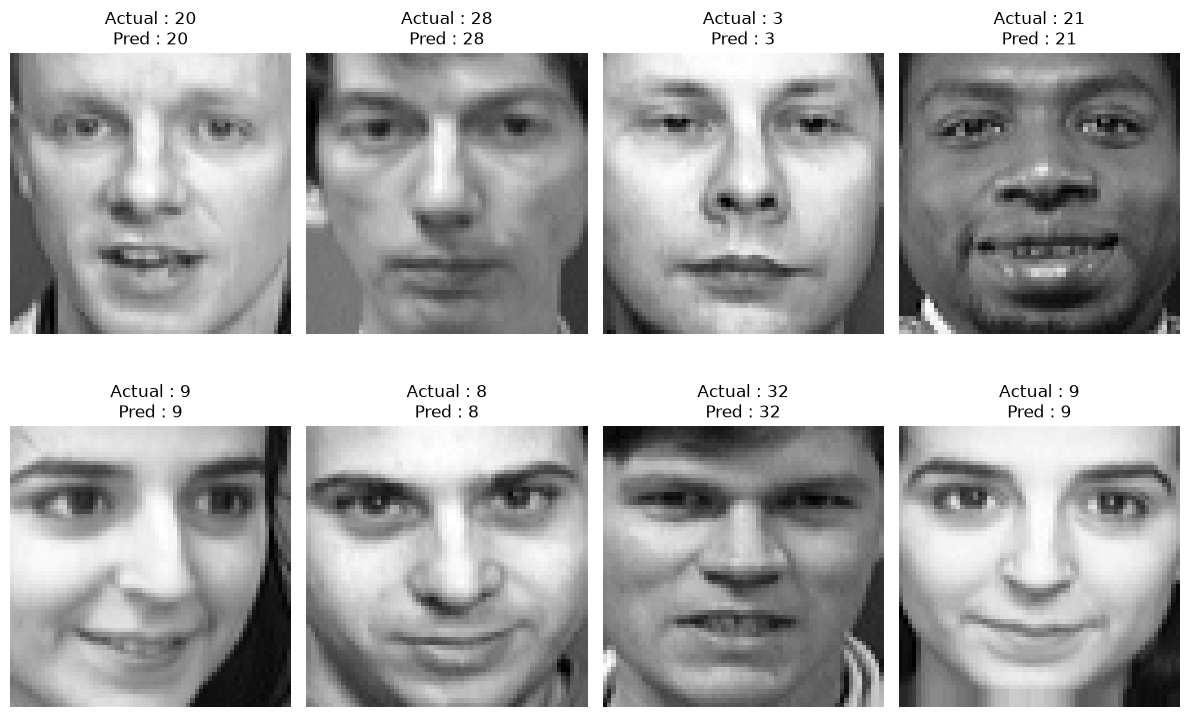

In [ ]:

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


faces = fetch_olivetti_faces()

X = faces.data
y = faces.target

print("Dataset Shape :", X.shape)
print("Number of Classes :", len(set(y)))


plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i].reshape(64,64), cmap="gray")
    plt.title("Person "+str(y[i]))
    plt.axis("off")

plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)



ann = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)


ann.fit(X_train, y_train)



y_pred = ann.predict(X_test)



accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)



print("\nClassification Report")

print(classification_report(y_test, y_pred))



ConfusionMatrixDisplay.from_estimator(
    ann,
    X_test,
    y_test
)

plt.show()


plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(X_test[i].reshape(64,64), cmap="gray")

    plt.title("Actual : "+str(y_test[i])+
              "\nPred : "+str(y_pred[i]))

    plt.axis("off")

plt.tight_layout()

plt.show()